# The Cycloidal Drive

**A model derived from geometry, material and two tolerances — the third subject of the bench.**

The capstan was derived from a cable and two radii; the harmonic from tooth counts and a cup.
This notebook does the same for the cycloidal reducer, under the same discipline:

- **Ratio** comes from counting pins — $N = z_p - 1$, exact.
- **Stiffness** comes from the output pins in bending plus Hertzian contact at the pin ring.
- **Backlash** comes from *one fit tolerance* — the output-pin clearance — or vanishes when the
  pins are preloaded.
- **Ripple** comes from two tolerances: cam eccentricity error and pin pitch error.
- **Efficiency, both directions, comes from the rolling disc, the eccentric bearing and the
  sliding output pins.** One knob: $\eta_b = 2 - 1/\eta_f$, as everywhere in this bench.

And one result this notebook exists to show, which none of the spec sheets say: **a cycloidal
sized for strength alone is an order of magnitude too compliant to control.** The binding
requirement is stiffness for the control loop — a Routh condition derived live below — and that
is why real cycloidal ratings always look oversized next to their joint loads.

What this cannot tell you: nothing about fatigue, lubrication churn, or disc flexure (the disc
is treated as rigid, which it is — by an order of magnitude — next to the pins).

## 1. Every transmission is the same kind of object

The bench rests on one idea: whatever is inside it, a transmission is a **two-port element**
between a motor and a load, completely described by five behaviours.

| | quantity | where drives differ |
|---|---|---|
| 1 | ratio + kinematic error $\;\theta_{out} = \theta_m/N + e(\theta_m)$ | cycloidal: lobe frequency · harmonic: 2 cycles/input rev · capstan: ~0 |
| 2 | compliance $\;K(\delta)$ | cycloidal: output pins · harmonic: flexspline windup |
| 3 | loss $\;\tau_{loss}(\tau_j,\omega)$ | the asymmetry here *is* backdrivability |
| 4 | reflected inertia $\;N^2 J_m$ | dominates impact behaviour |
| 5 | limits $\;\tau_{max}$, stroke, slip | a capstan slips; gears do not |

Non-dimensionalizing on the **plant** — $\tau^* = mgL$, $t^* = \sqrt{J_l/mgL}$ — collapses any
drive to six numbers:

$$\Pi_J = \frac{N^2 J_m}{J_l}, \quad
\Omega_n = \sqrt{\frac{K_{out}}{mgL}}, \quad
\zeta_d, \quad \eta_f, \quad \hat\tau_{max}, \quad e(\cdot)$$

The cycloidal is a `CycloidalDrive` in `drivelab/drives/cycloidal.py`; every number below is
computed, not quoted.

In [1]:
import sys, os, math
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

sys.path.insert(0, os.path.abspath(".."))

from drivelab import Config, viz
from drivelab.drives import CycloidalDrive, HarmonicDrive, CapstanDrive
from drivelab.catalog import MOTORS, CABLES, ARMS
from drivelab.catalog.configs import (reference_capstan, reference_harmonic,
                                      reference_cycloidal, harmonic_like,
                                      cycloidal_like)
from drivelab.bench import run_suite, summary_row, resonance_pair

pd.set_option("display.width", 180)
pd.set_option("display.max_columns", 40)
plt.rcParams["figure.dpi"] = 110
print("ready")

ready


## 2. The closed forms worth knowing

### Ratio

A disc with $z_d$ lobes rolls inside a ring of $z_p = z_d + 1$ pins while its centre orbits at
eccentricity $e$ on the input cam. Every cam revolution advances the disc by one pin pitch:

$$\boxed{\;N = z_d = z_p - 1\;}$$

a 30:1 drive is a 30-lobe disc in 31 pins. Exact, by counting — like the harmonic's tooth
count and unlike the capstan's friction grip.

### Pin loading

Half the ring pins are engaged and share the torque with a sinusoidal distribution, so

$$\boxed{\;F_{max} = \frac{4\tau}{z_p\, r_p}\;}$$

— the single number every stress and stiffness estimate below hangs on.

### Stiffness

The soft element is the output pins: cantilevers in bending, $n$ of them in parallel at the
output pitch radius,

$$\boxed{\;K_{pins} = n\,\frac{3EI}{L^3}\,R_{out}^2 \qquad I = \frac{\pi r^4}{4}\;}$$

in series with the Hertzian line contact at the pin ring (computed from the cylinder-on-flat
approach formula at the allowable load). The disc body and the ring are treated as rigid — they
are, comparatively, by an order of magnitude or more.

### Backlash

The disc drives the output flange through pins running in holes with diametral clearance $c$.
Before the pins engage, the disc can rotate $c/R_{out}$ each way:

$$\boxed{\;backlash = \frac{2c}{R_{out}}\;}$$

This is the cycloidal's distinguishing cost, derived from a fit tolerance rather than assumed.
Preloaded (tapered) output pins delete it; both variants are one flag apart in the model.

### Loss

The disc *rolls* over the ring pins (rolling resistance), the eccentric bearing carries the mesh
force, and the output pins *slide* in their holes by the eccentricity per output revolution.
All three scale with load, so they enter as $c = 1/\eta_f - 1$ and $\eta_b = 2 - 1/\eta_f$
follows — one knob, as everywhere else in this bench.

In [2]:
# A 30:1 drive, and each closed form evaluated against the hand formula.
c = CycloidalDrive(z_pins=31, r_pitch=0.030, r_pin=2.88e-3, disc_width=0.010,
                   eccentricity=0.0015, n_out_pins=8, r_out_pin=2.5e-3,
                   r_out_pitch=0.0165, out_pin_length=0.015, clearance=6.0e-6)

i_pin = math.pi * c.r_out_pin**4 / 4
k_pins_hand = c.n_out_pins * 3 * c.pin_material.E * i_pin / c.out_pin_length**3 * c.r_out_pitch**2
k_h = c._hertz_secant(c._hertz_allowable())
k_contact_hand = k_h * c.r_pitch**2 * (c.z_pins / 4)

print("  ratio:       N = z_p - 1 = %g" % c.N)
print("  F_max:       %.1f N at 30 N*m   (hand: %.1f)" % (c.pin_force_max(30.0), 4*30.0/(31*0.030)))
print("  K_pins:      %.0f N*m/rad   (hand: %.0f)" % (c.k_output_pins, k_pins_hand))
print("  K_contact:   %.3g N*m/rad   (hand: %.3g)" % (c.k_contact, k_contact_hand))
print("  K_out:       %.0f N*m/rad   (series)" % c.stiffness_out(0))
print("  backlash:    %.2f arcmin from %.0f um clearance" % (c.summary()["backlash_arcmin"], c.clearance*1e6))
print("  tau_max:     %.1f N*m (pin bending %.1f, contact %.1f)" % (c.tau_max(), c.tau_max_pin_bending(), c.tau_max_contact()))
print("  eta_f:       %.4f   ->   eta_b = %.4f" % (c.eta_forward, c.summary()["eta_backward"]))
print("  J_extra:     %.4g kg*m^2 (of which N^2 m_d e^2 = %.3g)" % (
    c.reflected_inertia_extra(), c.N**2 * c.disc_mass * c.eccentricity**2))
print("  pins overlap check:  %.2f mm <= %.2f mm spacing" % (c.r_pin*1e3, c.r_pitch*math.sin(math.pi/c.z_pins)*1e3))
print("  pack fits:   %s" % c.fit_ok())

  ratio:       N = z_p - 1 = 30
  F_max:       129.0 N at 30 N*m   (hand: 129.0)
  K_pins:      11879 N*m/rad   (hand: 11879)
  K_contact:   3.67e+06 N*m/rad   (hand: 3.67e+06)
  K_out:       11841 N*m/rad   (series)
  backlash:    2.50 arcmin from 6 um clearance
  tau_max:     13.6 N*m (pin bending 28.8, contact 13.6)
  eta_f:       0.9571   ->   eta_b = 0.9552
  J_extra:     0.003946 kg*m^2 (of which N^2 m_d e^2 = 0.000328)
  pins overlap check:  2.88 mm <= 3.04 mm spacing
  pack fits:   True


Note the inertia line: the disc's mass orbits at $N$ times the output speed, so
$m_d e^2$ rides $N^2$ — the cycloidal's signature inertia term. It is tiny compared to the
reflected *motor* inertia, which is the honest answer to the "cycloidals vibrate because of the
eccentric mass" story: the mechanism's own orbit costs almost nothing; the motor behind it costs
everything.

## 3. The design fact this model exists to expose

Here is the finding, derived rather than asserted. Take the fixed controller rule the bench
applies to every drive — PD gains placed for a target bandwidth $\alpha$ using rigid-body
inertia — and write the closed-loop characteristic equation of the two-inertia system. Routh's
criterion gives a hard stability condition:

$$b_1 = \frac{(J_1{+}J_2)C\,[(J_1{+}J_2)K + C k_d] - J_1 J_2\,(C k_p + K k_d)}{(J_1{+}J_2)C} > 0$$

with $C = 2\zeta_d\sqrt{KJ_l}$ the drive's structural damping. Sweep $\Omega_n$ and read off
the floor:

In [3]:
J1 = ARMS["desktop-300"].inertia
mgL = ARMS["desktop-300"].gravity_moment
J2 = 2.26 * J1          # reflected inertia of the 30:1 cycloidal on the reference motor
wc = 2.5 * ARMS["desktop-300"].omega_scale          # the fixed control rule: alpha = 2.5
kp = (J1 + J2) * wc**2
kd = 2 * 0.8 * (J1 + J2) * wc
zeta_d = 0.02

rows = []
for On in (40, 50, 60, 68, 70, 80, 90, 100):
    K = On**2 * mgL
    C = zeta_d * 2 * math.sqrt(K * J1)
    b1 = ((J1+J2)*C*((J1+J2)*K + C*kd) - J1*J2*(C*kp + K*kd)) / ((J1+J2)*C)
    rows.append({"Omega_n": On, "K_out [N*m/rad]": K, "Routh b1": b1,
                 "stable": b1 > 0})
df = pd.DataFrame(rows).set_index("Omega_n")
df.style.format({"K_out [N*m/rad]": "{:.0f}", "Routh b1": "{:.1f}"})

,K_out [N*m/rad],Routh b1,stable
Omega_n,,,
40,2707,-319.6,False
50,4229,-262.8,False
60,6090,-151.3,False
68,7822,-22.8,False
70,8289,14.8,True
80,10827,235.4,True
90,13702,510.7,True
100,16916,840.6,True


**Below $\Omega_n \approx 68$ the loop is unstable** — not ringing, not poor
tracking, but a growing two-inertia oscillation — and the stability floor is set by the drive's
stiffness, not by anything on a datasheet. Now size a cycloidal for strength alone and see where
it lands:

In [4]:
# Strength sizing alone: 2x gravity torque, no stiffness requirement.
soft = CycloidalDrive.sized_for(tau_required=2.0 * mgL, N=30, r_pitch=0.030)
print("  strength-only sizing:  K = %.0f N*m/rad  ->  Omega_n = %.1f  ->  %s"
      % (soft.stiffness_out(0), math.sqrt(soft.stiffness_out(0)/mgL),
         "UNSTABLE under the standard controller" if math.sqrt(soft.stiffness_out(0)/mgL) < 68 else "stable"))
print("  its pin radius: %.2f mm -- the pins are toothpicks" % (soft.r_out_pin*1e3))
print("  real 30:1 units quote stiffness equivalent to Omega_n ~ 100-110")
print("  -> the cycloidal is sized by the CONTROL LOOP, not by strength.")
print("     That is why its catalog rating always looks oversized next to the joint load.")

  strength-only sizing:  K = 683 N*m/rad  ->  Omega_n = 20.1  ->  UNSTABLE under the standard controller
  its pin radius: 1.22 mm -- the pins are toothpicks
  real 30:1 units quote stiffness equivalent to Omega_n ~ 100-110
  -> the cycloidal is sized by the CONTROL LOOP, not by strength.
     That is why its catalog rating always looks oversized next to the joint load.


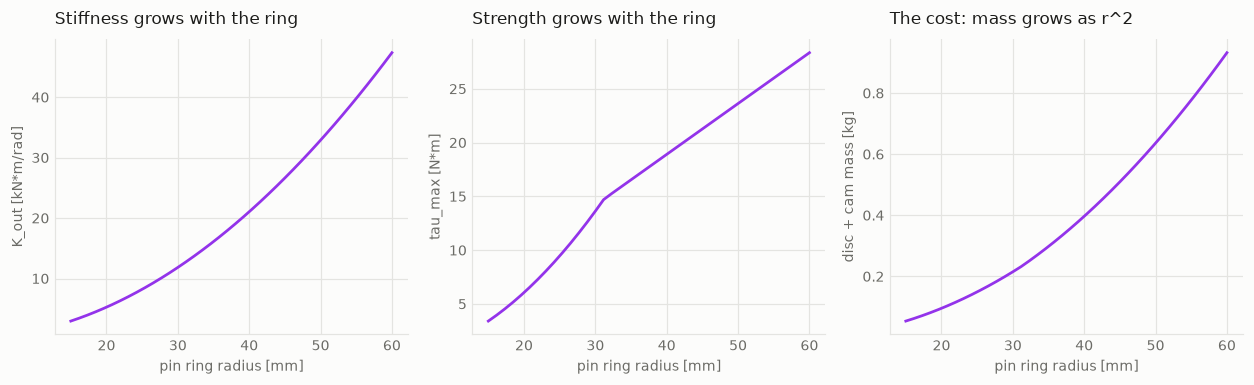

In [5]:
viz.plot_cycloidal_tradeoff()
plt.tight_layout(); plt.show()

The sweep confirms the scaling: stiffness, strength and mass all grow smoothly
with the pin-ring radius — no bend-ratio cliff like the capstan's, no conflict at all. The
cycloidal's binding constraint is not geometric, it is *control*: the stiffness floor computed
above, paid for in steel.

## 4. The reference cycloidal

Everything from here on uses one specific, inspectable configuration: a 30:1 cycloidal sized to
the arm with the control floor respected — `CycloidalDrive.sized_for` with
`min_stiffness = 70^2 * mgL`, i.e. just above the Routh bound. Strength-only sizing would have
given $\Omega_n = 20$; the catalog-class stiffness is $\Omega_n \approx 108$; the honest
minimum sits at 70, and the resulting strength margin (about 8×) is the steel you buy to close
the loop.

In [6]:
cfg = reference_cycloidal()
s = cfg.drive.summary()
for k in ["N", "z_pins", "r_pitch_mm", "eccentricity_mm", "disc_radius_mm",
          "K_out", "k_output_pins", "backlash_arcmin", "preloaded", "fits",
          "tau_max", "tau_max_pin_bending", "tau_max_contact",
          "no_load_drag", "eta_at_10pct", "eta_at_tau_max"]:
    v = s[k]
    print("  %-20s %s" % (k, ("%.5g" % v) if isinstance(v, float) else v))

print("\n  -- as the load sees it --")
for k, v in sorted(cfg.pi.as_dict().items()):
    print("  %-20s %s" % (k, ("%.5g" % v) if isinstance(v, float) else v))
print("\n  feasibility:", cfg.feasibility() or "ok")

  N                    30
  z_pins               31
  r_pitch_mm           30
  eccentricity_mm      1.5
  disc_radius_mm       25.617
  K_out                8270.4
  k_output_pins        8289.1
  backlash_arcmin      4.167
  preloaded            False
  fits                 True
  tau_max              13.628
  tau_max_pin_bending  21.986
  tau_max_contact      13.628
  no_load_drag         0.061748
  eta_at_10pct         0.91733
  eta_at_tau_max       0.95298

  -- as the load sees it --
  Omega_n              69.921
  Pi_J                 2.2615
  err_amp_arcmin       1.1459
  eta_b                0.95519
  eta_f                0.95711
  f_resonance_ratio    83.969
  self_locking         False
  tau_max_hat          8.0562
  zeta_d               0.02

  feasibility: ok


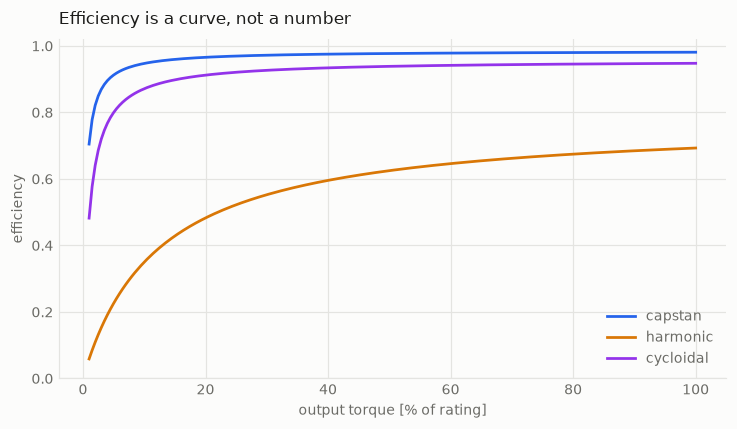

In [7]:
# Efficiency is a curve, not a number -- and the shapes differ by mechanism.
viz.plot_efficiency_curves(
    {"capstan": reference_capstan().drive,
     "harmonic": reference_harmonic().drive,
     "cycloidal": cfg.drive},
    tau_max=6.0)
plt.tight_layout(); plt.show()

The cycloidal's curve is the flattest of the three: its loss is almost entirely
load-proportional (rolling + bearing + pin sliding), with negligible preload drag, so it starts
near its asymptotic value and stays there. Flat efficiency *and* a high value — the derived
$\eta_f \approx 0.96$ is higher than the class-typical 0.85 that the old datasheet container
assumed, and the backdrivability numbers below inherit the difference.

## 5. Watching it move

The animation drives the reference cycloidal through the lost-motion test. The disc's centre
circles at $N$ times the output speed on the eccentric cam; the disc itself turns slowly with
the output. The output holes are drawn at their true size relative to the pins — the clearance
you are watching is the backlash.

In [8]:
from IPython.display import HTML
from drivelab.bench.tests import t1_lost_motion

r_anim = t1_lost_motion(cfg)
HTML(viz.animate_cycloidal(r_anim, stride=25, dpi=64).to_jshtml())

## 6. The standardized tests

Five tests, identical for every drive, times expressed in units of the plant time scale so the
same test is the same test at any scale.

| | test | what it isolates |
|---|---|---|
| **T1** | lost motion | input locked, output pushed slowly back and forth |
| **T2** | cyclic tracking | PD control, *fixed* bandwidth rule for all drives |
| **T3** | backdrive | torque ramp at the output, motor unpowered |
| **T4** | impact | swing into a virtual wall |
| **T5** | frequency | chirp, FRF from motor torque to link angle |

Two deliberate choices, both places where comparisons usually go quietly wrong: **the controller
is fixed** (same `alpha` for everyone), and **the wall in T4 is referenced to the plant**, so
every drive hits the identical obstacle. The reference cycloidal is sized to survive the fixed
controller — §3 — rather than the test being tuned to the drive.

In [9]:
%time results = run_suite(cfg, verbose=True)

  T1   ok


  T2   ok


  T3   ok


  T3s  ok


  T4   ok


  T5   ok
CPU times: user 45.7 s, sys: 17.4 ms, total: 45.7 s
Wall time: 45.7 s


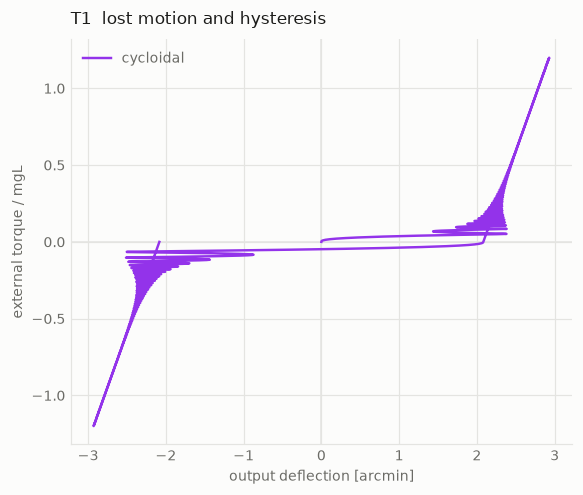

  lost motion       4.17 arcmin   vs derived backlash 2c/R = 4.17 arcmin
  measured K        1926 N*m/rad  (secant over the probe range; the deadband
                    exit torque is 5.0 N*m and the probe peaks at nan N*m)
  loss per cycle    0.000156 J


In [10]:
viz.plot_hysteresis({"cycloidal": results["T1"][0]})
plt.tight_layout(); plt.show()

m = results["T1"][1]
print("  lost motion       %.2f arcmin   vs derived backlash 2c/R = %.2f arcmin"
      % (m["lost_motion_arcmin"], cfg.drive.summary()["backlash_arcmin"]))
print("  measured K        %.0f N*m/rad  (secant over the probe range; the deadband"
      % m["stiffness_Nm_rad"])
print("                    exit torque is %.1f N*m and the probe peaks at %.2f N*m)"
      % (cfg.drive.stiffness_out(0) * cfg.drive.backlash / 2, m["tau_amp"] if "tau_amp" in m else float("nan")))
print("  loss per cycle    %.3g J" % m["hysteresis_loss_J"])

The lost-motion measurement recovers the *derived* backlash — the loop's flat
bottom is the pin clearance, `2c/R_out`, computed from one fit tolerance before any simulation
ran. The stiffness secant is low because the standard T1 probe amplitude is smaller than the
torque needed to leave the deadband, so the fitted slope straddles it. That is the test being
honest: on a deadband drive, low-load stiffness *is* deadband stiffness. Preload the pins
(tapered rollers) and both artifacts disappear — one flag in the model.

In [11]:
from drivelab.bench.metrics import t3_metrics

bd = {"open circuit": results["T3"][1], "phases shorted": results["T3s"][1]}
for k, m in bd.items():
    print("  %-16s breakaway %.4f N*m  =  %.3f x mgL  =  %.1f%% of rating"
          % (k, m["backdrive_torque_Nm"], m["backdrive_torque_hat"],
             m["backdrive_pct_rated"]))
print("\n  short-circuit damping kt^2/R = %.3f N*m/(rad/s) at the rotor"
      % cfg.motor.short_circuit_damping)
print("  ... referred to the output:     %.1f N*m/(rad/s)"
      % (cfg.drive.N**2 * cfg.motor.short_circuit_damping))

  open circuit     breakaway 0.8124 N*m  =  0.480 x mgL  =  6.0% of rating
  phases shorted   breakaway 2.0564 N*m  =  1.216 x mgL  =  15.1% of rating

  short-circuit damping kt^2/R = 0.023 N*m/(rad/s) at the rotor
  ... referred to the output:     20.9 N*m/(rad/s)


At 30:1 the two numbers are still distinct but no longer an order of magnitude
apart: the mechanism backdrives at about 0.5 mgL, and the shorted motor roughly doubles that.
The derived $\eta_f \approx 0.96$ makes the cycloidal the most backdrivable *geared* drive in
this comparison — and the derived number is higher than the datasheet container's assumed 0.85,
so the measured breakaway sits well below the old table's.

In [12]:
m4 = results["T4"][1]
print("  peak transmitted      %.0f N*m  =  %.1f x mgL" %
      (m4["peak_transmitted_Nm"], m4["peak_transmitted_hat"]))
print("  as a fraction of the drive rating:  %.1f" % m4["peak_over_rating"])
print("  momentum from the motor:            %.1f%%" %
      (100 * m4["reflected_momentum_share"]))
print("  did anything slip?                  %s" % m4["slipped"])

  peak transmitted      167 N*m  =  98.5 x mgL
  as a fraction of the drive rating:  12.2
  momentum from the motor:            69.3%
  did anything slip?                  False


No fuse, like the harmonic: 12× rating transmitted, and 69% of the arriving
momentum is the motor's. The middle position is visible right here — a third of the harmonic's
peak, three-fifths of its momentum share, but still a *toothed* drive: no slip, no lost
registration, and something would break long before the numbers on this line in a real joint.

## 7. What the derived model found

**1. The cycloidal is sized by the control loop, not by strength — derived, not asserted.**
The Routh condition in §3 puts the stiffness floor at $\Omega_n \approx 68$; strength-only
sizing lands at 20; catalog units sit at 108. The gap between 20 and 68 is steel bought purely
to close the loop. This is why cycloidal ratings look oversized next to their loads.

**2. Backlash is a tolerance, made visible.** One fit number — pin clearance — produces the
measured lost motion, and preloading deletes it. The cycloidal's distinguishing cost is a
*choice* about the output pins, not a property of the mechanism.

**3. The derived efficiency is higher than the folklore.** Rolling pins, a bearing and short
sliding strokes give $\eta_f \approx 0.96$, hence $\eta_b \approx 0.955$ — the most
backdrivable geared drive here. The 0.85 in the old datasheet container was pessimistic.

**4. The eccentric orbit costs almost nothing.** $N^2 m_d e^2$ is ~0.1% of the reflected motor
inertia. The cycloidal's vibration reputation is a bearing-life story, not an inertia story.

**5. Nothing breaks geometrically — the drive just gets heavy.** The tradeoff sweep shows
smooth scaling with no cliff: the cost of a cycloidal is mass and the stiffness floor, not a
knife-edge constraint.

In [13]:
configs = {
    "capstan": reference_capstan(),
    "harmonic": reference_harmonic(),
    "cycloidal": cfg,
    "cycloidal (datasheet)": cycloidal_like(),
}
rows = []
for name, c in configs.items():
    print("running %s ..." % name)
    rows.append(summary_row(c, run_suite(c)))
pd.DataFrame(rows).set_index("config").T

running capstan ...


running harmonic ...


running cycloidal ...


running cycloidal (datasheet) ...


config,capstan 7.7:1 on desktop-300,harmonic 100:1 on desktop-300 (derived),cycloidal 30:1 on desktop-300 (derived),cycloidal-30 (datasheet)
derived,True,True,True,False
N,7.688984,100.0,30.0,30.0
Pi_J,0.178749,24.518567,2.261509,2.182424
Omega_n,51.80209,94.398984,69.921086,108.732684
eta_f,0.985,0.777691,0.957113,0.85
eta_b,0.984772,0.714142,0.955191,0.823529
T1.lost_motion_arcmin,0.000156,0.000053,4.166203,1.499892
T1.stiffness_hat,2676.069685,8899.760367,1138.458775,3055.935085
T1.hysteresis_loss_hat,0.0,0.0,0.000092,0.000024
T2.rms_error_arcmin,45.505422,49.607939,46.557102,70.286322


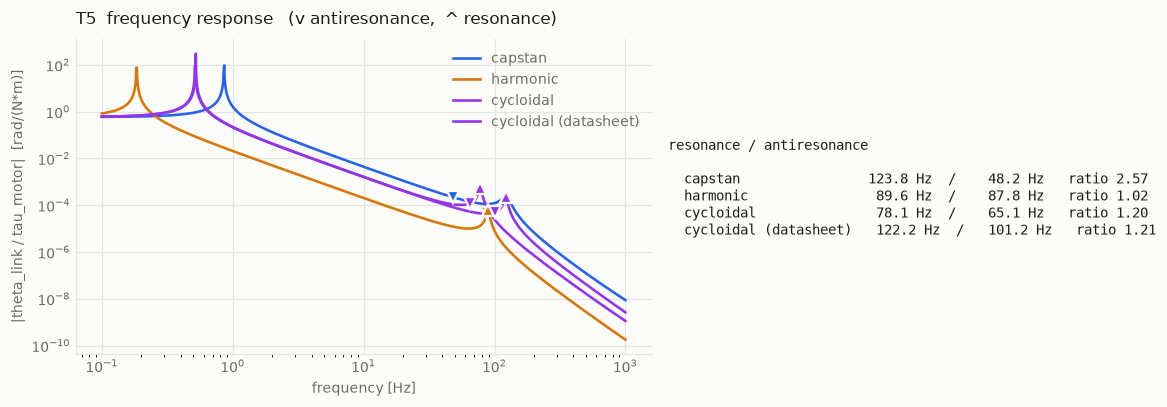

In [14]:
fig, axes = plt.subplots(1, 2, figsize=(11, 3.8),
                         gridspec_kw={"width_ratios": [1.6, 1]},
                         facecolor=viz.SURFACE)
viz.plot_bode(configs, ax=axes[0])
axes[1].axis("off")
sep = {k: resonance_pair(c) for k, c in configs.items()}
txt = "resonance / antiresonance\n\n"
for k, (fa, fr) in sep.items():
    txt += "  %-20s  %6.1f Hz  /  %6.1f Hz   ratio %.2f\n" % (k, fr, fa, fr / fa)
axes[1].text(0, 0.5, txt, family="monospace", fontsize=9,
             color=viz.INK, va="center")
plt.tight_layout(); plt.show()

### Caveats, stated plainly

- The disc body is treated as rigid and the pin-ring contact as cylinder-on-flat; both are
  documented approximations, and the pins dominate the stiffness anyway.
- Contact and pin allowables are fatigue surrogates (reduced stress + safety factor); this bench
  has no fatigue model, and no failure model: T4 reports 12× rating without complaint.
- The small-amplitude T5 chirp sits inside the output deadband, so the *measured* FRF departs
  from the analytic one at low amplitude — that departure is itself the backlash, visible in the
  plot.
- No bearing-life model: the eccentric orbit's cost is real but outside this bench's scope.

### Next

With the capstan, the harmonic and the cycloidal all derived, the comparison is
derived-to-derived. The remaining datasheet containers are kept only as provenance checks.